In [88]:
import numpy as np
import matplotlib.pyplot as plt
    
from sklearn.linear_model import LinearRegression
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

from src.network_simulator import MultiplexSimulator, create_orthogonal_sets
from src.variational_bayes import VariationalBayes
from src.helper_functions.phi_gradients import compute_gradient_theta_phi_k

# Simulate from the model

In [101]:
num_nodes = 250
num_layers = 10
num_global_groups = 3
max_num_layer_groups = 3
features_length = 3
num_adj_samps = 1

global_group_sizes = [100, 100, 50]
# features = create_orthogonal_sets(global_group_sizes, 0.001, features_length)
features = np.zeros((num_nodes, features_length))
# means = [
#     [25, 0, 0],   # Mean for group 1
#     [0, 25, 0], # Mean for group 2
#     [0, 0, 25]  # Mean for group 3
# ]
means = [
    [5, 5, 5],
    [0, 0, 0], # Mean for group 1
    [-5, -5, -5]]
covariances = [
    [[1, 0, 0], [0, 1, 0], [0, 0, 1]],   # Covariance for group 1
    [[1, 0, 0], [0, 1, 0], [0, 0, 1]], # Covariance for group 2
    [[1, 0, 0], [0, 1, 0], [0, 0, 1]]    # Covariance for group 3
]
# Generate features for each group
start_idx = 0
for i, (mean, cov) in enumerate(zip(means, covariances)):
    end_idx = start_idx + global_group_sizes[i]
    features[start_idx:end_idx, :features_length] = (
        np.random.multivariate_normal(mean, cov, size=global_group_sizes[i])
        )
    start_idx = end_idx

# 0 mean, 1 variance scaling
scaler = StandardScaler()
features = scaler.fit_transform(features)

features = np.ones((num_nodes, 1))
features_length = 1

# Connectivity matrix
rho_matrix = np.array(
    [[0.9, 0.5, 0.2],
     [0.4, 0.7, 0.05],
     [0.2, 0.01, 0.6]]
)
# rho_matrix = np.array(
#     [[0.8, 0.7, 0.5],
#      [0.6, 0.75, 0.55],
#      [0.5, 0.4, 0.6]]
# )

# Layer probability vectors
alpha = 0
gamma1 = [1-2*alpha, alpha, alpha]
gamma2 = [alpha, 1-2*alpha, alpha]
gamma3 = [alpha, alpha, 1-2*alpha]
# gamma1 = [1, 0, 0]
# gamma2 = [0, 1, 0]
# gamma3 = [0, 0, 1]
def sample_layer_groups(num_layers, gammas, global_group_sizes):
    num_layer_groups = len(gammas[0])
    num_glob_groups = len(global_group_sizes)
    N = np.array(global_group_sizes).sum()
    layer_groups = np.zeros((num_layers, num_nodes))

    for layer in range(num_layers):
        samples = []
        for global_group in range(num_glob_groups):
            samples.append(
                np.random.choice(num_layer_groups,
                                 p=gammas[global_group],
                                 size=global_group_sizes[global_group])
            )
        layer_groups[layer,:] = (
            np.concatenate(samples)
        )

    return layer_groups

layer_groups = sample_layer_groups(num_layers, 
                                   [gamma1, gamma2, gamma3], 
                                   global_group_sizes)
layer_groups = layer_groups.astype(int)

MS = MultiplexSimulator(num_nodes=num_nodes, num_layers=num_layers, 
                        num_glob_groups=num_global_groups,
                        max_num_layer_groups=max_num_layer_groups,
                        features=features, specify=True, 
                        rho_matrix=rho_matrix, layer_groups=layer_groups,
                        num_adj_samps=num_adj_samps)

MS.sample_network()

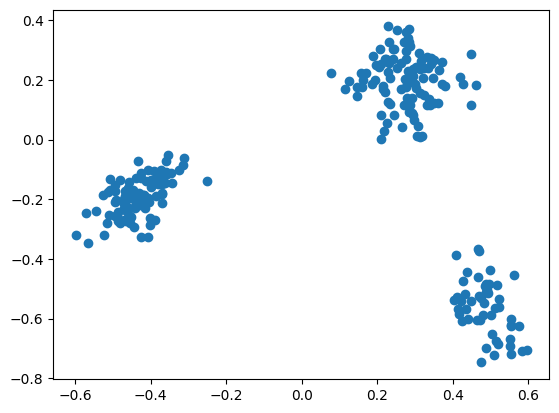

In [103]:
from scipy.linalg import svd

k_max=3
A_l = MS.adjacency_tensor[0,:,:].copy()
U, Sigma, Vt = svd(A_l)
# Left and right eigenvectors
left_evecs = U[:,:k_max]; right_evecs = Vt.T[:,:k_max]
#Compute the embeddings
Sigma_half = np.sqrt(Sigma)
X = left_evecs @ np.diag(Sigma_half[:k_max])
X_prime = right_evecs @ np.diag(Sigma_half[:k_max])

plt.plot(X[:,1], X[:,2], 'o')

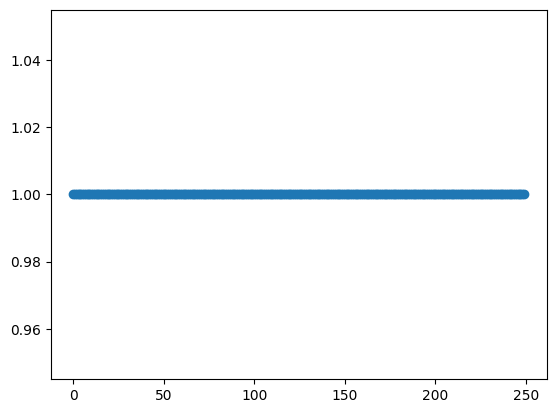

In [105]:
plt.plot(features[:,0], features[:,1], 'o')

# Run the fitting procedure

In [107]:
VB = VariationalBayes(num_nodes=num_nodes, num_layers=num_layers,
                      adj_tensor=MS.adjacency_tensor, features=features,
                      M_w=3, M_z=3, num_fp_its=2, num_adj_samps=num_adj_samps, 
                      uniform_w=True)
# VB._initialise_parameters()
VB.run_VB_scheme(n_CAVI_its=10, num_mc=10000, max_num_grad_steps=30, alpha=0.1,
                 alpha_set_theta=[0.1], alpha_set_sigma=[0.01],
                 eps_ELBO_phi=10**-8, max_ELBO_phi_dec=10, max_ELBO_dec=10,
                 ADAM_type='single', lr_theta=0.5, lr_sigma=0.1)

...Iteration 1 of 10...
ELBO_init: -560592.0377222076
...Updating rho...
ELBO after rho: -314944.4853374457
...Updating gamma...
ELBO after gamma: -310904.31301805255
...Updating phi_0...
ELBO after phi_0: -310900.3152297934
...Updating phi...
ELBO after phi: -310781.2404508015
...Updating sigma2...
ELBO after sigma2: -310781.0582931604
...Updating z...
ELBO after z: -310781.02429788955
...Updating w...
ELBO after w: -310778.4065790307
ELBO_track: -310778.36050419265
...Iteration 2 of 10...
...Updating rho...
ELBO after rho: -310778.38159944996
...Updating gamma...
ELBO after gamma: -310778.3415850782
...Updating phi_0...
ELBO after phi_0: -310776.5740460615
...Updating phi...
ELBO after phi: -310775.5432416646
...Updating sigma2...
ELBO after sigma2: -310775.23484751594
...Updating z...
ELBO after z: -310775.2188019799
...Updating w...
ELBO after w: -310775.24090625235
ELBO_track: -310775.2600451708
...Iteration 3 of 10...
...Updating rho...
ELBO after rho: -310775.2181554035
...Updat

KeyboardInterrupt: 

In [108]:
VB.phi_w.argmax(axis=1)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [12]:
global_groups = np.concatenate(
    (np.repeat(0, global_group_sizes[0]),
     np.repeat(1, global_group_sizes[1]),
     np.repeat(2, global_group_sizes[2]))
)
print(adjusted_rand_score(VB.phi_w_best.argmax(axis=1), global_groups))

1.0


In [13]:
VB.phi_w_best.argmax(axis=1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [86]:
def reconstruct_gamma(alpha: np.array, beta: np.array):
    """
    Reconstruct gamma vectors using MAP estimates.
    
    Parameters:
        - alpha: array of shape (M_u x M_u).
        - beta: array of shape (M_u x M_u)
    """
    gamma = np.zeros_like(alpha)
    for k in range(gamma.shape[0]):
        for s in range(gamma.shape[1]):
            if s == 0:
                gamma[k,s] = alpha[k,s] / (alpha[k,s] + beta[k,s])
            else:
                gamma[k,s] = (
                    alpha[k,s] / (alpha[k,s] + beta[k,s]) 
                )
                gamma[k,s] *= (1 - alpha[k,:s] / (alpha[k,:s] + beta[k,:s])).prod()

    return gamma / gamma.sum(axis=1, keepdims=True)

reconstruct_gamma(VB.alpha_gamma_best, VB.beta_gamma_best)

array([[9.98751478e-04, 9.98751810e-01, 2.49438514e-04],
       [9.99376636e-01, 4.98690936e-04, 1.24672734e-04],
       [9.99000335e-04, 9.98002665e-04, 9.98002997e-01]])

In [4]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [87]:
for i in range(10):
    print(f"ARI for layer {i} groups: {adjusted_rand_score(VB.phi_z.argmax(axis=2)[i], layer_groups[i])}")

print(f"ARI for global groups: {adjusted_rand_score(VB.phi_w.argmax(axis=1), global_groups)}")

ARI for layer 0 groups: 1.0
ARI for layer 1 groups: 1.0
ARI for layer 2 groups: 1.0
ARI for layer 3 groups: 1.0
ARI for layer 4 groups: 1.0
ARI for layer 5 groups: 1.0
ARI for layer 6 groups: 1.0
ARI for layer 7 groups: 1.0
ARI for layer 8 groups: 1.0
ARI for layer 9 groups: 1.0
ARI for global groups: 1.0


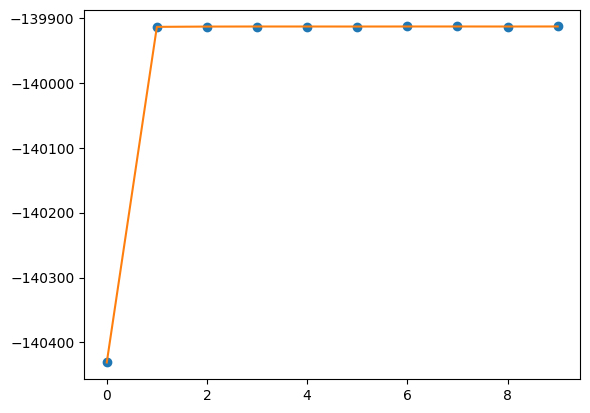

In [37]:
plt.plot(VB.ELBO_store_full[:25], 'o')
plt.plot(VB.ELBO_store_full[:25])

In [52]:
VB._update_q_z()
print(VB.phi_z)

[[[2.66312520e-138 1.00000000e+000 5.12003599e-014]
  [2.94293388e-109 9.60422125e-009 9.99999990e-001]
  [1.00000000e+000 1.64220830e-148 8.78893800e-141]
  ...
  [1.00000000e+000 2.19136871e-153 2.12842740e-145]
  [1.00000000e+000 9.41222210e-153 4.40972310e-150]
  [7.83501542e-129 3.77378441e-007 9.99999623e-001]]

 [[1.00000000e+000 1.03165511e-135 2.75083860e-137]
  [1.00000000e+000 8.09205864e-132 8.89923970e-130]
  [6.83057443e-122 1.24151649e-006 9.99998758e-001]
  ...
  [1.00000000e+000 3.40896841e-132 6.08437703e-135]
  [1.00000000e+000 5.21156866e-144 5.65380379e-138]
  [1.00000000e+000 1.35514037e-135 1.69988444e-137]]

 [[1.68672219e-138 6.43042127e-020 1.00000000e+000]
  [3.92391826e-141 1.75305891e-017 1.00000000e+000]
  [1.20260475e-111 1.06241713e-019 1.00000000e+000]
  ...
  [1.00000000e+000 6.40787453e-139 4.82941454e-142]
  [9.55190579e-118 1.00000000e+000 1.12460093e-015]
  [1.00000000e+000 2.31962072e-095 6.48435634e-101]]

 ...

 [[9.36901060e-149 1.00000000e+000

In [19]:
VB.phi_w_store[-1][VB.phi_w_store[-1].argmax(axis=1) == 1].round(4)

array([[1.000e-04, 6.561e-01, 3.437e-01],
       [1.210e-02, 6.077e-01, 3.802e-01],
       [1.000e-04, 9.784e-01, 2.150e-02],
       [0.000e+00, 9.917e-01, 8.300e-03],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 9.999e-01, 1.000e-04],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 9.999e-01, 1.000e-04],
       [0.000e+00, 9.919e-01, 8.100e-03],
       [0.000e+00, 9.999e-01, 1.000e-04],
       [0.000e+00, 9.999e-01, 1.000e-04],
       [0.000e+00, 9.986e-01, 1.400e-03],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00],
       [0.000e+00, 9.984e-01, 1.600e-03],
       [0.000e+00, 9.997e-01, 3.000e-04],
       [0.000e+00, 1.000e+00, 0.00

In [53]:
VB.phi_w_best.argmax(axis=1)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
#%%
import pandas as pd
import numpy as np
import networkx as nx
import yaml
import pickle
import os

restrict_type = 'ym'

## Load in the processed POLECAT data 
df = pd.read_csv("simulations/POLECAT/csv/polecat.csv")

# Create a network object
df_network_raw = df[['Actor Country Id', 'Recipient Country Id', 
                     'Quad Code Id', 'Event Year Id', 'Event Month Id',
                     'Event Week Id', 'Event Day Id']]

print("Data loaded")

"""
THIS WILL RESTRICT TO A PARTICULAR TIME WINDOW AND THEN AGREGGATE.

For example, df_network_y will take all data from that year, and construct a weighted
adjacency matrix.
"""

def create_network_y(year: int, df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given year.
    """
    df_network_y = df_network[df_network['Event Year Id'] == year].copy()
    
    # Reset to 0 index
    df_network_y = df_network_y.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                            'Event Day Id'])

    # Weighted network
    df_network_y = df_network_y.drop_duplicates()
    counts = df_network_y.groupby(df_network_y.columns.tolist()).size().reset_index(name='Weight')
    df_network_y = pd.merge(df_network_y, counts, on=df_network_y.columns.to_list(), how='left') 
    df_network_y = df_network_y.drop_duplicates()
    
    return df_network_y

def create_network_ym(year: int, month: int, df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given year and month.
    """
    df_network_ym = df_network[df_network['Event Year Id'] == year].copy()
    
    # Reset to 0 index
    df_network_ym.loc[:, 'Event Month Id'] = df_network_ym['Event Month Id'] - df_network_ym['Event Month Id'].min()
    df_network_ym.loc[:, 'Event Day Id'] = df_network_ym['Event Day Id'] - df_network_ym['Event Day Id'].min()
    df_network_ym = df_network_ym[df_network_ym['Event Month Id'] == month]
    
    df_network_ym = df_network_ym.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id'])

    # Weighted network 
    df_network_ym = df_network_ym.drop_duplicates()
    counts = df_network_ym.groupby(df_network_ym.columns.tolist()).size().reset_index(name='Weight')
    df_network_ym = pd.merge(df_network_ym, counts, on=df_network_ym.columns.to_list(), how='left')
    df_network_ym = df_network_ym.drop_duplicates()
    
    return df_network_ym

def create_network_ymd(year: int, month: int, day: int, 
                       df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given year, month and day.
    """
    df_network_ymd = df_network[df_network['Event Year Id'] == year].copy()
    
    # Reset to 0 index
    df_network_ymd.loc[:, 'Event Month Id'] = df_network_ymd['Event Month Id'] - df_network_ymd['Event Month Id'].min()
    df_network_ymd = df_network_ymd[df_network_ymd['Event Month Id'] == month]
    
    df_network_ymd.loc[:, 'Event Day Id'] = df_network_ymd['Event Day Id'] - df_network_ymd['Event Day Id'].min()    
    df_network_ymd = df_network_ymd[df_network_ymd['Event Day Id'] == day]

    df_network_ymd = df_network_ymd.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 'Event Day Id'])

    # Weighted network
    df_network_ymd = df_network_ymd.drop_duplicates()
    counts = df_network_ymd.groupby(df_network_ymd.columns.tolist()).size().reset_index(name='Weight')
    df_network_ymd = pd.merge(df_network_ymd, counts, on=df_network_ymd.columns.to_list(), how='left')
    df_network_ymd = df_network_ymd.drop_duplicates()
    
    return df_network_ymd

def create_network_w(week: int, df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given week.
    """
    df_network_w = df_network[(df_network['Event Week Id'] == week)].copy()
    df_network_w = df_network_w.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id'])

    # Weighted network
    df_network_w = df_network_w.drop_duplicates()
    counts = df_network_w.groupby(df_network_w.columns.tolist()).size().reset_index(name='Weight')
    df_network_w = pd.merge(df_network_w, counts, on=df_network_w.columns.to_list(), how='left') 
    df_network_w = df_network_w.drop_duplicates()
    
    return df_network_w

# Create the dataset
if restrict_type == 'y':
    print("...Beginning processing...")
    year = 0
    
    ## Construct the adjacency tensor
    df_network = create_network_y(year=year)
    # df_network['Weight'] = np.where(df_network['Weight'] >= 1, 1, df_network['Weight'])
    df_network = df_network.groupby(
        ['Actor Country Id', 'Recipient Country Id', 'Quad Code Id'], 
        as_index=False)['Weight'].sum()
    print("...df_network created....")
    
    # Get unique values from Actor and Recipient
    node_list = sorted(set(df_network['Actor Country Id']).union(set(df_network['Recipient Country Id'])))

    # Create dictionaries mapping the Id's as per "map_country" to 0,...,len(node_list)
    raw_to_network = {old_id: new_id for new_id, old_id in enumerate(node_list)}
    network_to_raw = {new_id: old_id for old_id, new_id in raw_to_network.items()}
    
    # Map the columns
    df_network['Actor Country Id'] = df_network['Actor Country Id'].replace(raw_to_network)
    df_network['Recipient Country Id'] = df_network['Recipient Country Id'].replace(raw_to_network)
    
    num_nodes = len(node_list)
    num_layers = 4
    
    adj_tensor = np.zeros((num_layers, num_nodes, num_nodes))

    for code in range(4):
        print(f"Creating G_layer: {code}")
        G_layer = nx.DiGraph()
        G_layer.add_nodes_from(node_list)

        # Extract relevant rows
        filtered_df = df_network[df_network['Quad Code Id'] == code]

        # Add weighted edges
        G_layer.add_weighted_edges_from(
            (actor, recipient, weight) 
            for actor, recipient, weight in zip(
                filtered_df['Actor Country Id'], # These have been mapped
                filtered_df['Recipient Country Id'],
                filtered_df['Weight']  
            )
            if actor in node_list and recipient in node_list
        )

        adj_tensor[code,:,:] = nx.to_numpy_array(G_layer, weight='weight')
    
    # print("...Saving...")    
    # np.save(f'output/adjacency_tensor/adj_tensor_{array_index}.npy', adj_tensor)
    # with open(f'output/raw_to_network/raw_to_network_{array_index}.pkl', 'wb') as f:
    #     pickle.dump(raw_to_network, f)
    # with open(f'output/network_to_raw/network_to_raw_{array_index}.pkl', 'wb') as f:
    #     pickle.dump(network_to_raw, f)
    # print("...Saved...")

elif restrict_type == 'ym':
    print("...Beginning processing...")
    year = 0
    month = 0
    
    ## Construct the adjacency tensor
    df_network = create_network_ym(year=year, month=month)
    df_network = df_network.groupby(
        ['Actor Country Id', 'Recipient Country Id', 'Quad Code Id'], 
        as_index=False)['Weight'].sum()
    print("...df_network created...")
    	
    # Get unique values from Actor and Recipient
    node_list = sorted(set(df_network['Actor Country Id']).union(set(df_network['Recipient Country Id'])))

    # Create dictionaries mapping the Id's as per "map_country" to 0,...,len(node_list)
    raw_to_network = {old_id: new_id for new_id, old_id in enumerate(node_list)}
    network_to_raw = {new_id: old_id for old_id, new_id in raw_to_network.items()}
    
    # Map the columns
    df_network['Actor Country Id'] = df_network['Actor Country Id'].replace(raw_to_network)
    df_network['Recipient Country Id'] = df_network['Recipient Country Id'].replace(raw_to_network)
    
    num_nodes = len(node_list)
    num_layers = 4
    
    adj_tensor = np.zeros((num_layers, num_nodes, num_nodes))

    for code in range(4):
        print(f"Creating G_layer: {code}")
        G_layer = nx.DiGraph()
        G_layer.add_nodes_from(node_list)

        # Extract relevant rows
        filtered_df = df_network[df_network['Quad Code Id'] == code]

        # Add weighted edges
        G_layer.add_weighted_edges_from(
            (actor, recipient, weight) 
            for actor, recipient, weight in zip(
                filtered_df['Actor Country Id'], 
                filtered_df['Recipient Country Id'],
                filtered_df['Weight']  
            )
            if actor in node_list and recipient in node_list
        )

        adj_tensor[code,:,:] = nx.to_numpy_array(G_layer, weight='weight')
    
elif restrict_type == 'w':
    print("...Beginning processing...")
    week = 10
    
    ## Construct the adjacency tensor
    df_network = create_network_w(week=week)
    df_network = df_network.groupby(
        ['Actor Country Id', 'Recipient Country Id', 'Quad Code Id'], 
        as_index=False)['Weight'].sum()
    print("...df_network created...")
    	
    # Get unique values from Actor and Recipient
    node_list = sorted(set(df_network['Actor Country Id']).union(set(df_network['Recipient Country Id'])))

    # Create dictionaries mapping the Id's as per "map_country" to 0,...,len(node_list)
    raw_to_network = {old_id: new_id for new_id, old_id in enumerate(node_list)}
    network_to_raw = {new_id: old_id for old_id, new_id in raw_to_network.items()}
    
    # Map the columns
    df_network['Actor Country Id'] = df_network['Actor Country Id'].replace(raw_to_network)
    df_network['Recipient Country Id'] = df_network['Recipient Country Id'].replace(raw_to_network)
    
    num_nodes = len(node_list)
    num_layers = 4
    
    adj_tensor = np.zeros((num_layers, num_nodes, num_nodes))

    for code in range(4):
        print(f"Creating G_layer: {code}")
        G_layer = nx.DiGraph()
        G_layer.add_nodes_from(node_list)

        # Extract relevant rows
        filtered_df = df_network[df_network['Quad Code Id'] == code]

        # Add weighted edges
        G_layer.add_weighted_edges_from(
            (actor, recipient, weight) 
            for actor, recipient, weight in zip(
                filtered_df['Actor Country Id'], 
                filtered_df['Recipient Country Id'],
                filtered_df['Weight']  
            )
            if actor in node_list and recipient in node_list
        )

        adj_tensor[code,:,:] = nx.to_numpy_array(G_layer, weight='weight')
    
elif restrict_type == 'ymd':
    print("...Beginning processing...")
    year = 0
    month = 0
    day = 0
    
    ## Construct the adjacency tensor
    df_network = create_network_ymd(year=year, month=month, day=day)
    df_network = df_network.groupby(
        ['Actor Country Id', 'Recipient Country Id', 'Quad Code Id'], 
        as_index=False)['Weight'].sum()
    print("...df_network created...")
    	
    # Get unique values from Actor and Recipient
    node_list = sorted(set(df_network['Actor Country Id']).union(set(df_network['Recipient Country Id'])))

    # Create dictionaries mapping the Id's as per "map_country" to 0,...,len(node_list)
    raw_to_network = {old_id: new_id for new_id, old_id in enumerate(node_list)}
    network_to_raw = {new_id: old_id for old_id, new_id in raw_to_network.items()}
    
    # Map the columns
    df_network['Actor Country Id'] = df_network['Actor Country Id'].replace(raw_to_network)
    df_network['Recipient Country Id'] = df_network['Recipient Country Id'].replace(raw_to_network)
    
    num_nodes = len(node_list)
    num_layers = 4
    
    adj_tensor = np.zeros((num_layers, num_nodes, num_nodes))

    for code in range(4):
        print(f"Creating G_layer: {code}")
        G_layer = nx.DiGraph()
        G_layer.add_nodes_from(node_list)

        # Extract relevant rows
        filtered_df = df_network[df_network['Quad Code Id'] == code]

        # Add weighted edges
        G_layer.add_weighted_edges_from(
            (actor, recipient, weight) 
            for actor, recipient, weight in zip(
                filtered_df['Actor Country Id'], 
                filtered_df['Recipient Country Id'],
                filtered_df['Weight']  
            )
            if actor in node_list and recipient in node_list
        )

        adj_tensor[code,:,:] = nx.to_numpy_array(G_layer, weight='weight')

Data loaded
...Beginning processing...
...df_network created...
Creating G_layer: 0
Creating G_layer: 1
Creating G_layer: 2
Creating G_layer: 3


In [40]:
G1 = nx.from_numpy_array(adj_tensor[0])
G2 = nx.from_numpy_array(adj_tensor[1])
G3 = nx.from_numpy_array(adj_tensor[2])
G4 = nx.from_numpy_array(adj_tensor[3])

G1d = nx.DiGraph(adj_tensor[0])
G2d = nx.DiGraph(adj_tensor[1])
G3d = nx.DiGraph(adj_tensor[2])
G4d = nx.DiGraph(adj_tensor[3])



In [98]:
G1.adj

AdjacencyView({0: {25: {'weight': 1.0}, 79: {'weight': 1.0}, 84: {'weight': 1.0}, 85: {'weight': 1.0}, 92: {'weight': 1.0}, 97: {'weight': 1.0}, 103: {'weight': 1.0}, 106: {'weight': 2.0}, 28: {'weight': 1.0}}, 1: {}, 2: {}, 3: {106: {'weight': 1.0}}, 4: {48: {'weight': 1.0}, 105: {'weight': 1.0}, 106: {'weight': 1.0}, 111: {'weight': 1.0}, 46: {'weight': 1.0}}, 5: {106: {'weight': 2.0}, 83: {'weight': 1.0}}, 6: {}, 7: {}, 8: {43: {'weight': 1.0}, 97: {'weight': 1.0}, 105: {'weight': 1.0}}, 9: {76: {'weight': 1.0}, 105: {'weight': 1.0}}, 10: {106: {'weight': 1.0}}, 11: {71: {'weight': 1.0}}, 12: {}, 13: {}, 14: {}, 15: {105: {'weight': 1.0}}, 16: {33: {'weight': 1.0}, 47: {'weight': 1.0}, 79: {'weight': 1.0}, 105: {'weight': 1.0}, 106: {'weight': 3.0}, 74: {'weight': 1.0}, 97: {'weight': 1.0}}, 17: {}, 18: {}, 19: {}, 20: {53: {'weight': 1.0}, 82: {'weight': 1.0}, 100: {'weight': 1.0}, 106: {'weight': 3.0}, 33: {'weight': 1.0}, 43: {'weight': 1.0}, 48: {'weight': 1.0}}, 21: {33: {'weig

In [78]:
max_comp_G1 = max(nx.weakly_connected_components(G1d))
max_comp_G2 = max(nx.weakly_connected_components(G2d))
max_comp_G3 = max(nx.weakly_connected_components(G3d))

max_comp_G = max_comp_G1.intersection(max_comp_G2, max_comp_G3)

# Restrict each layer to nodes in max_comp_G
G1d_sub = G1d.subgraph(max_comp_G).copy()
G2d_sub = G2d.subgraph(max_comp_G).copy()
G3d_sub = G3d.subgraph(max_comp_G).copy()

# Find the largest weakly connected component in each restricted graph
max_comp_G1_sub = max(nx.weakly_connected_components(G1d_sub), key=len)
max_comp_G2_sub = max(nx.weakly_connected_components(G2d_sub), key=len)
max_comp_G3_sub = max(nx.weakly_connected_components(G3d_sub), key=len)

# Take the intersection again to ensure connectivity in all layers
final_nodes = max_comp_G1_sub.intersection(max_comp_G2_sub, max_comp_G3_sub)

# Create the final subgraphs
G1d_final = G1d.subgraph(final_nodes).copy()
G2d_final = G2d.subgraph(final_nodes).copy()
G3d_final = G3d.subgraph(final_nodes).copy()



In [90]:
graph = G2d_final
for node in graph.nodes:
    if graph.degree(node) == 0:
        print(node)
        
print(len(graph.nodes))

26
48


In [85]:
import networkx as nx

# Step 1: Create directed graphs from adjacency tensors
G1d = nx.DiGraph(adj_tensor[0])
G2d = nx.DiGraph(adj_tensor[1])
G3d = nx.DiGraph(adj_tensor[2])

# Step 2: Get the largest weakly connected component in each layer
max_comp_G1 = max(nx.weakly_connected_components(G1d), key=len)
max_comp_G2 = max(nx.weakly_connected_components(G2d), key=len)
max_comp_G3 = max(nx.weakly_connected_components(G3d), key=len)

# Step 3: Compute the intersection of the largest components (common nodes)
max_comp_G = max_comp_G1 & max_comp_G2 & max_comp_G3  # Ensures same nodes in all layers

# Step 4: Restrict each graph to only the common nodes
G1d_sub = G1d.subgraph(max_comp_G).copy()
G2d_sub = G2d.subgraph(max_comp_G).copy()
G3d_sub = G3d.subgraph(max_comp_G).copy()

# Step 5: Remove isolated nodes (nodes without edges)
def remove_isolated_nodes(G):
    return G.subgraph([node for node in G.nodes if G.degree(node) > 0]).copy()

G1d_clean = remove_isolated_nodes(G1d_sub)
G2d_clean = remove_isolated_nodes(G2d_sub)
G3d_clean = remove_isolated_nodes(G3d_sub)

# Step 6: Find the final common node set after removing isolated nodes
final_nodes = set(G1d_clean.nodes) & set(G2d_clean.nodes) & set(G3d_clean.nodes)

# Step 7: Ensure that all layers have the exact same nodes
G1d_final = G1d_clean.subgraph(final_nodes).copy()
G2d_final = G2d_clean.subgraph(final_nodes).copy()
G3d_final = G3d_clean.subgraph(final_nodes).copy()


In [101]:
df_network

,Actor Country Id,Recipient Country Id,Quad Code Id,Weight
0,0,6,3,1
1,0,34,0,1
2,0,61,0,2
3,0,61,2,1
4,0,102,0,1
...,...,...,...,...
1254,143,112,0,6
1255,143,138,0,1
1256,145,3,1,1
1257,145,49,2,1


In [86]:
import pandas as pd
from data.POLECAT.construct_POLECAT_adjacency_functions import (
    create_network_y, create_network_ym, create_network_ymd, create_network_w,
    construct_layer_adjacency_tensors
)

year = 0
month = 2

df = pd.read_csv("data/POLECAT/processed_data/polecat.csv")
# Create a network object
df_network_raw = df[['Actor Country Id', 'Recipient Country Id', 
                     'Quad Code Id', 'Event Year Id', 'Event Month Id',
                     'Event Week Id', 'Event Day Id']]

df_network = create_network_ym(year=year, month=month, df_network=df_network_raw)

adj_tensor, raw_to_network, network_to_raw = construct_layer_adjacency_tensors(df_network, num_layers=3)

In [74]:
raw_to_network.keys()

dict_keys([8, 9, 13, 23, 31, 35, 36, 38, 44, 48, 50, 56, 58, 59, 62, 63, 76, 78, 79, 80, 81, 82, 84, 87, 91, 94, 97, 110, 112, 121, 126, 127, 129, 131, 137, 139, 141, 142, 150, 159, 160, 161, 166, 168, 171, 177, 181, 182, 183, 184, 188])

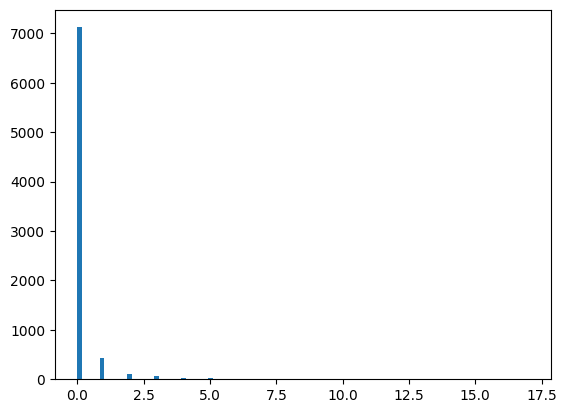

In [55]:
import matplotlib.pyplot as plt

plt.hist(adj_tensor.flatten(), bins=100);